# 6.3 Pointing & Aligment Errors

In this notebook we detail the most important sources of error that affect the barycentric stellar positions from an perfect performing payload. Generally one can classify two main sources of error: those who are related to the pointing precision of the platform from mission quarter to the next, and those errors that are related to the physical integration and assembly of the payload which always will have small misalignments present. The latter is further enhanced when the spacecraft is launched to space and vibrations will introduce further misalignment and slight tilts of different camera components (like the lenses and CCDs). Below we show how to include a realistic distribution of the platform pointing and camera misalignment errors. 

### Setup notebook

In [7]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [8]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd

# PlatoSim libraries
import platosim.noise as ns
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## 6.3.1 - Platform pointing errors
---

The pointing of the PLATO platform from mission quarter to the next will be extremely precise, however, not perfect. This means that the Pointing Repeatability Error (PREs) will introduce small barycentric shifts of the stars every time the observations are interrupted (i.e. also after safe mode events, etc). 

Let's assume we want to generate a PRE file for the LOPS2 pointing. First we fetch this pointing with:

In [9]:
alpha, delta, kappa = ut.getPointingField('LOPS2')
alpha, delta, kappa

(95.31043, -47.88693, 193.9947)

We can now use the function `ns.getPRE()` to generate random pointing offset. Below we simulate 100 realisations of the PRE just for illustrative purposes- and we use a requirement that the errors should be within a $3 \sigma$ compared to that of the mission requirement:


Change of coordinates [arcsec]
    quarter       yaw     pitch      roll
0         1  1.043697 -1.160232 -0.928650
1         2 -1.409884  0.852746  0.726670
2         3  2.022688 -0.632771 -0.606261
3         4  1.673885 -2.836800 -2.210295
4         5 -0.475291  0.250636  0.217761
..      ...       ...       ...       ...
94       95  0.927537 -0.967066 -0.777994
95       96 -2.001140  1.129210  0.971471
96       97 -0.062888  0.550325  0.410809
97       98  0.177791 -0.736509 -0.556220
98       99  0.572248 -1.047086 -0.812708

[99 rows x 4 columns]

New ICRS coordinates [deg]
    quarter         RA        Dec     kappa
0         1  95.310720 -47.887252 -0.000258
1         2  95.310038 -47.886693  0.000202
2         3  95.310992 -47.887106 -0.000168
3         4  95.310895 -47.887718 -0.000614
4         5  95.310298 -47.886860  0.000060
..      ...        ...        ...       ...
94       95  95.310688 -47.887199 -0.000216
95       96  95.309874 -47.886616  0.000270
96       97  95.3

<IPython.core.display.Javascript object>


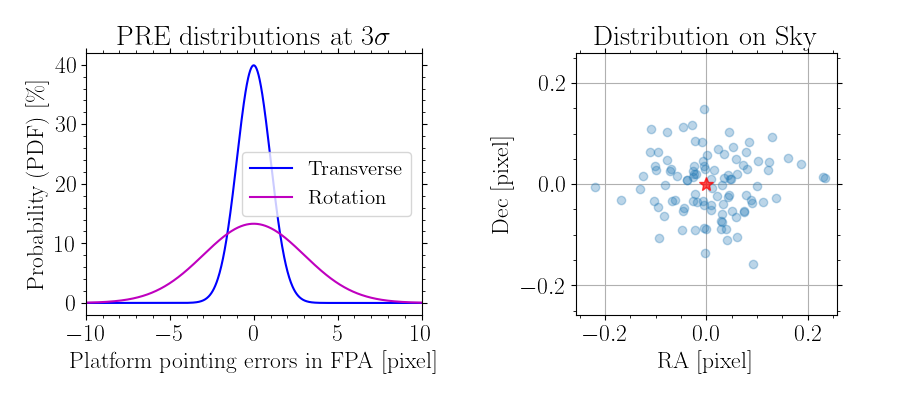

In [16]:
PRE = ns.getPRE(alpha, delta, kappa, range(1,100), sigma=3, show_table=True, plot=True)

From the above figures its shown that the mission requirement of drawing the PRE from a $3 \sigma$ distribution results in small barycentric pixel displacement of the stars less than a few pixels.

---
## 6.3.2 - Camera misalignments
---


Camera alignment errors for all 24 N-CAMs [pixel]
          Alt         Az        Yaw      Pitch       Roll
0    5.586948  -4.823283 -21.584128   5.586948  16.760845
1    7.604314   0.957503 -21.855439   7.604314  22.812941
2  -13.124507   8.465335  47.838857 -13.124507 -39.373522
3   -7.189940   5.159116  26.728936  -7.189940 -21.569821
4   -3.143592  -3.473175   5.957602  -3.143592  -9.430777
5    4.600134  -3.799934 -17.600335   4.600134  13.800401
6    9.914888   1.892636 -27.852027   9.914888  29.744663
7   -2.083476   3.783859  10.034287  -2.083476  -6.250428
8   -6.703697  -1.271613  18.839477  -6.703697 -20.111090
9    2.910001  -1.322859 -10.052861   2.910001   8.730003
10  11.614859   5.328219 -29.516356  11.614859  34.844576
11 -10.969689   7.160939  40.070006 -10.969689 -32.909067
12  -6.193033  -1.950732  16.628366  -6.193033 -18.579098
13   5.483178  -0.521184 -16.970719   5.483178  16.449535
14  -2.414830   2.262462   9.506953  -2.414830  -7.244491
15  -6.113110   0.812

<IPython.core.display.Javascript object>


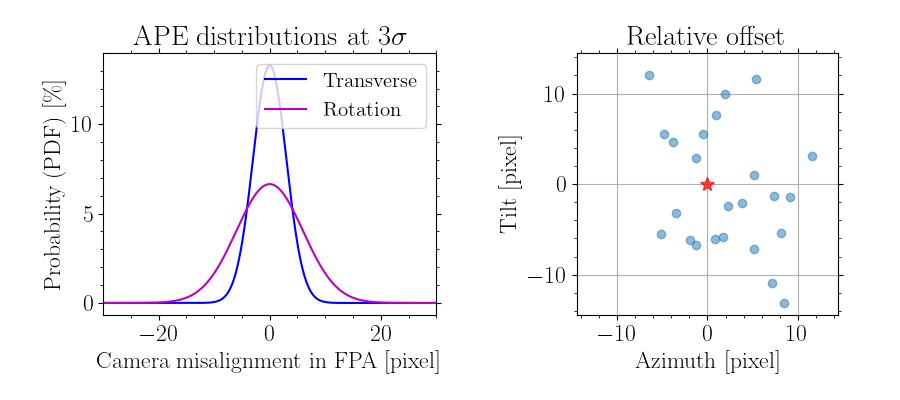

In [11]:
APE = ns.getAPE(alpha, delta, kappa, sigma=3, show_table=True, plot=True)